# TP1 Vision Artificial - Panoramica

#### by: Tomás Vocos Conesa - Martin Ariel DeHieronymis - Zoe Larisson
    

### Imports:


In [37]:
import numpy as np 
from matplotlib import pyplot as plt
import cv2

from utils import *

La celda de abajo permite modificar utils.py sin necesidad de reiniciar el kernel para que se actualicen los cambios 

In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Deteccion y Descripcion de caracteristicas Visuales
testeo deteccion y descripcion con funciones de Opencv en aluna de las imagenes

In [39]:
cuadro_0_img = cv2.imread('inputs/cuadro_0.jpg')
cuadro_1_img = cv2.imread('inputs/cuadro_1.jpg')
cuadro_2_img = cv2.imread('inputs/cuadro_2.jpg')

#### SIFT:
Esta funcion da los keypoints y sus respectivos descriptores. Hay muchas funciones de este estilo en la libreria pero en teoria esta de es las mas robustas. 

La misma internamente convierte la imagen a grayscale y trabaja con un solo canal de intensidad. Debido a esto no hace falta manualmente pasar a grayscale

In [40]:
sift = cv2.SIFT_create(nfeatures=200)
kp_cuadro0, descr_cuadro0 = sift.detectAndCompute(cuadro_0_img, None)

img_kp0=graf_keypoints(cuadro_0_img,kp_cuadro0)


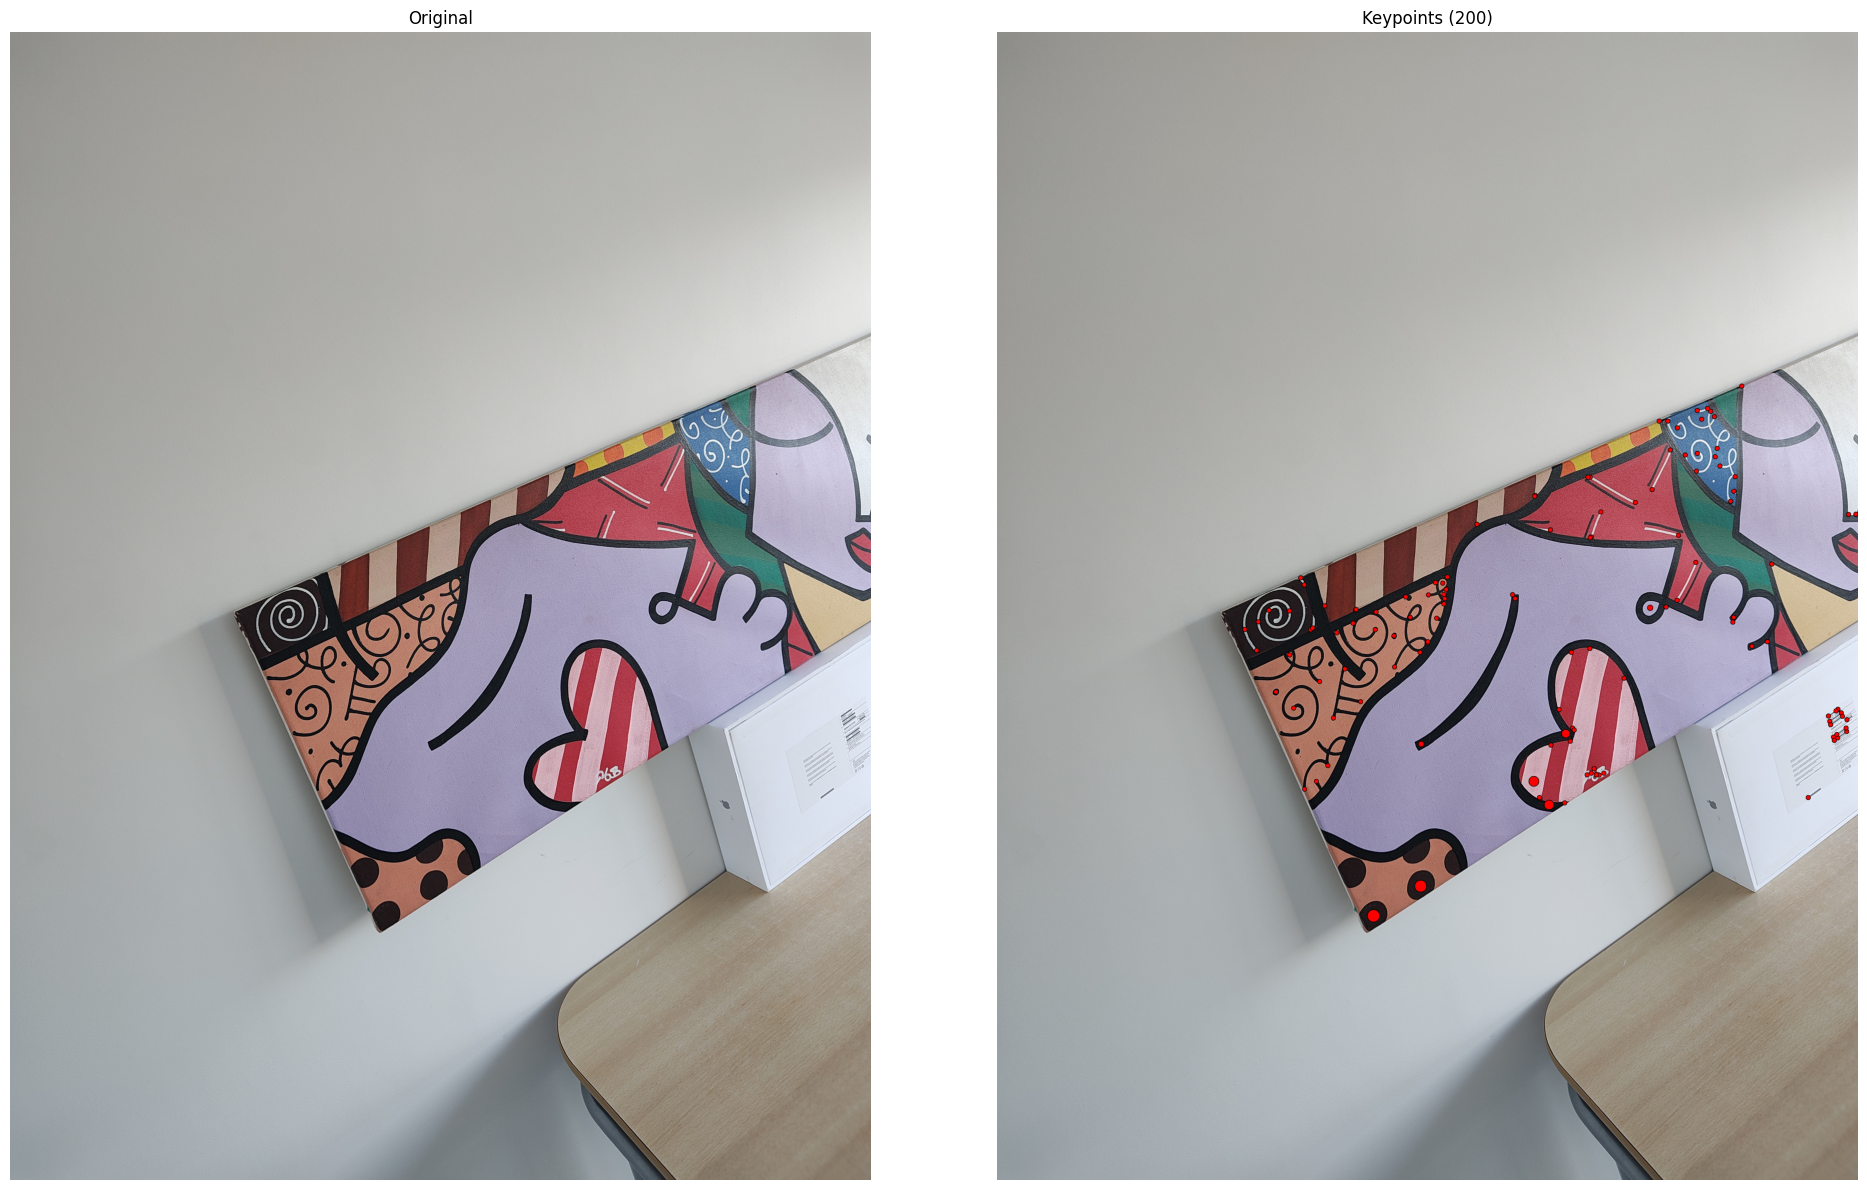

In [41]:
img_kp0_rgb = cv2.cvtColor(img_kp0, cv2.COLOR_BGR2RGB)
img_prueba_rgb = cv2.cvtColor(cuadro_0_img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(20, 12))  # más grande
axs[0].imshow(img_prueba_rgb)
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(img_kp0_rgb)
axs[1].set_title(f'Keypoints ({len(kp_cuadro0)})')
axs[1].axis('off')

plt.tight_layout()
plt.show()

Hago lo mismo con las otras imagenes del cuadro y veo como matchenan los features 

### Funciones auxiliares: matching y ploteo
Modularizo el matching y el ploteo en dos funciones:
- `plot_matches`: dibuja los matches entre dos imagenes usando `cv2.drawMatches`
- `detectar_matches`: matchea descriptores con `BFMatcher` + ratio test de Lowe, y opcionalmente llama a `plot_matches` para graficar

Matches buenos: 51 de 200 totales


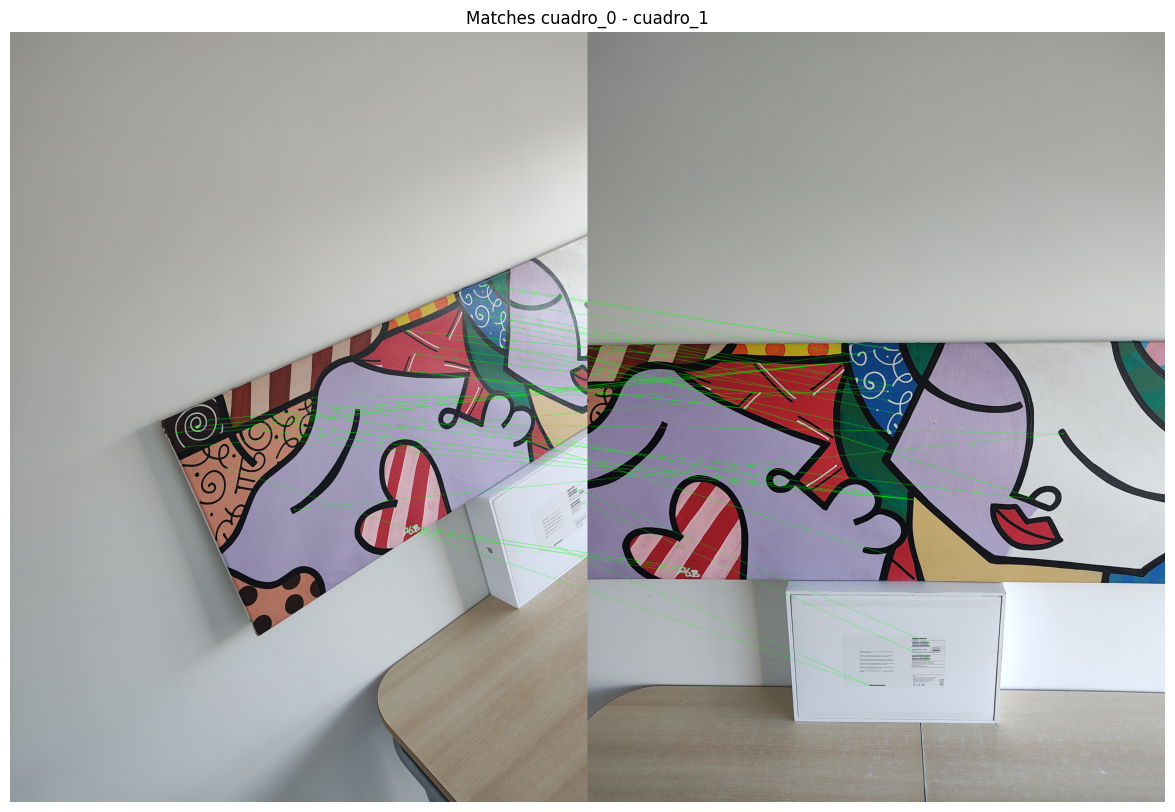

In [42]:
kp_cuadro1, descr_cuadro1 = sift.detectAndCompute(cuadro_1_img, None)

good_matches_01 = detectar_matches(
    descr_cuadro0, descr_cuadro1, plot=True,
    img1=cuadro_0_img, kp1=kp_cuadro0, img2=cuadro_1_img, kp2=kp_cuadro1,
    titulo='Matches cuadro_0 - cuadro_1'
)

Matches buenos: 46 de 200 totales


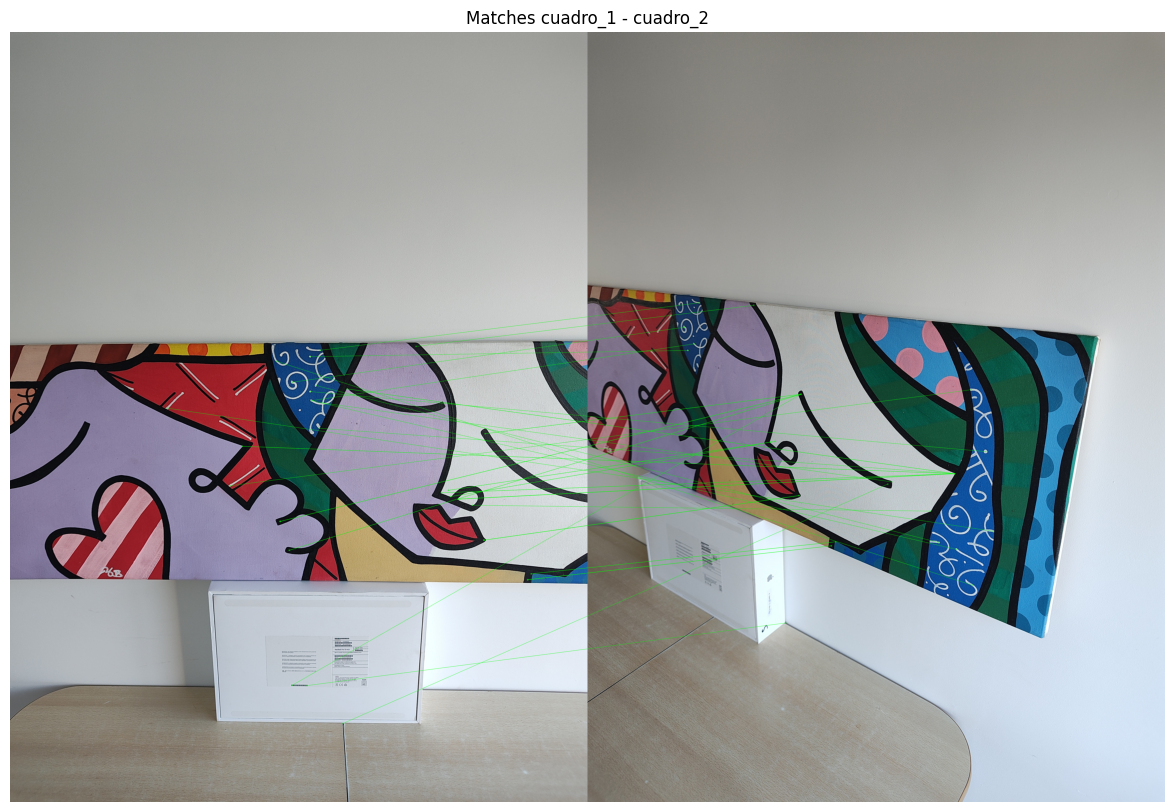

In [43]:
kp_cuadro2, descr_cuadro2 = sift.detectAndCompute(cuadro_2_img, None)

good_matches_12 = detectar_matches(
    descr_cuadro1, descr_cuadro2, plot=True,
    img1=cuadro_1_img, kp1=kp_cuadro1, img2=cuadro_2_img, kp2=kp_cuadro2,
    titulo='Matches cuadro_1 - cuadro_2'
)

# 3.2 A-MNS

In [44]:
keys_all0,desc_all0,kp_anms0=calc_anms(cuadro_0_img,_print=True)

Keypoints detectados originalmente: 13636
Keypoints tras ANMS: 200


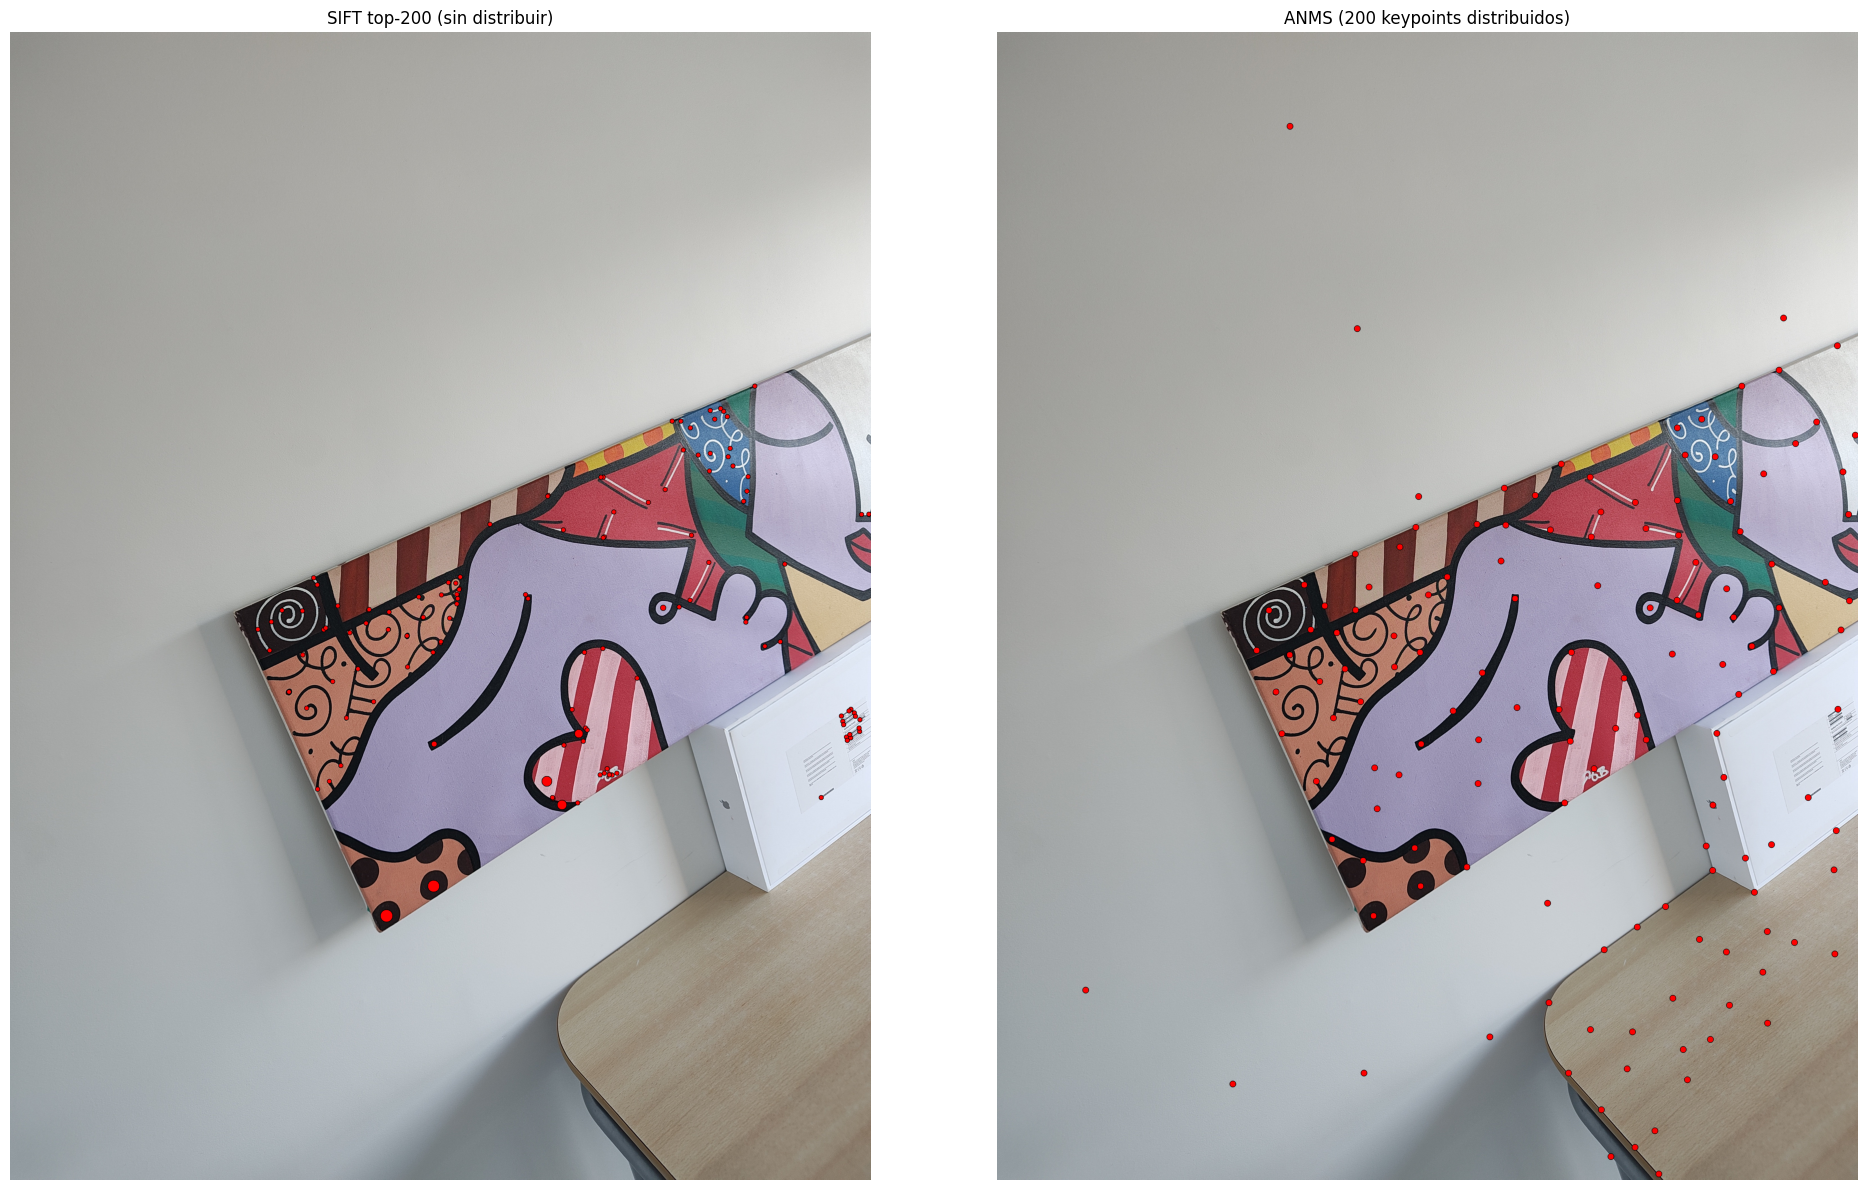

In [45]:
img_anms = cuadro_0_img.copy()
img_anms=graf_keypoints(cuadro_0_img,kp_anms0,r=10)
fig, axs = plt.subplots(1, 2, figsize=(20, 12))

axs[0].imshow(cv2.cvtColor(img_kp0, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'SIFT top-{len(kp_cuadro0)} (sin distribuir)')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_anms, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'ANMS ({len(kp_anms0)} keypoints distribuidos)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

Realizamos Anms para todas las partes de la imagen

In [50]:
keys_all1,desc_all1,kp_anms1=calc_anms(cuadro_1_img,_print=False)
keys_all2,desc_all2,kp_anms2=calc_anms(cuadro_2_img,_print=False)

In [47]:
img_kp1=graf_keypoints(cuadro_1_img,kp_cuadro1)
img_kp2=graf_keypoints(cuadro_2_img,kp_cuadro2,r=10)


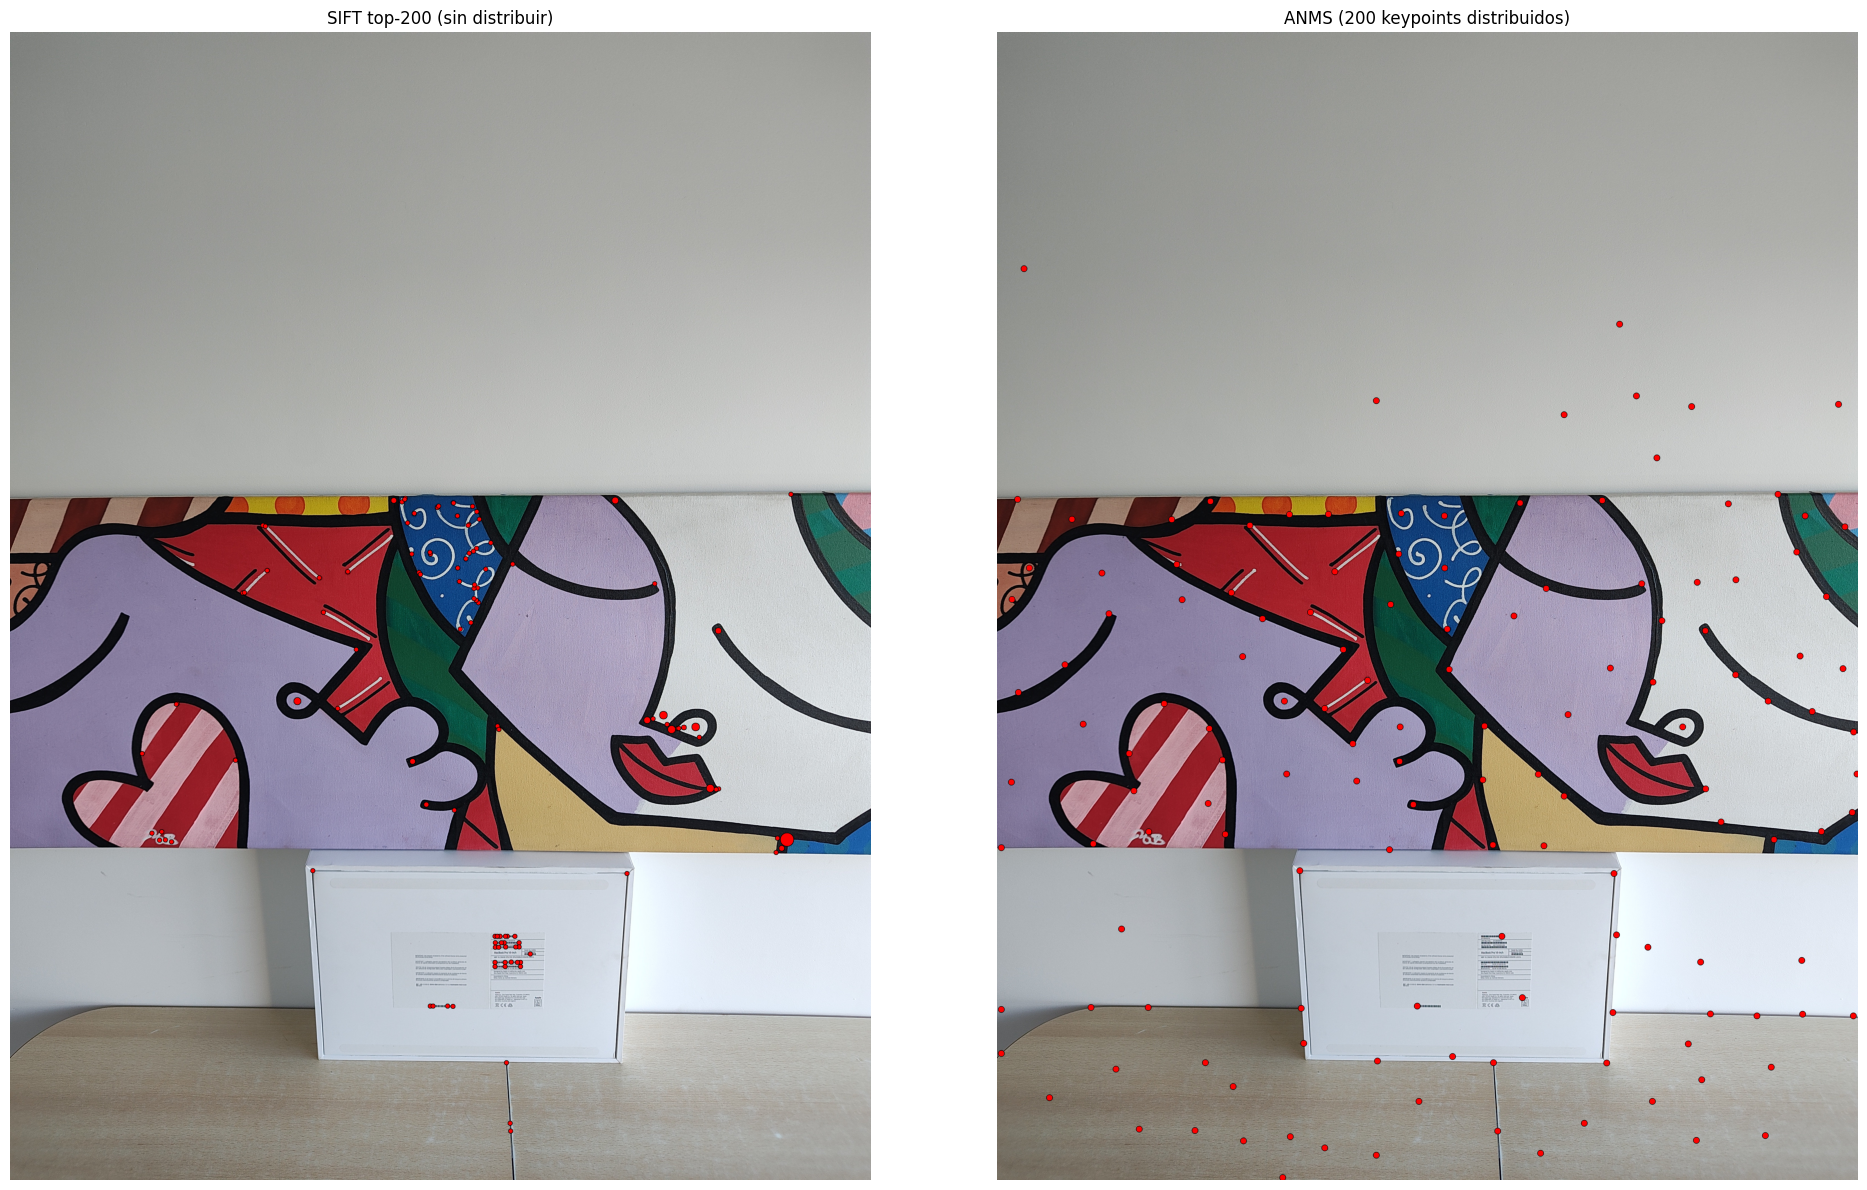

In [48]:
img_anms_1=graf_keypoints(cuadro_1_img,kp_anms1,r=10)
fig, axs = plt.subplots(1, 2, figsize=(20, 12))

axs[0].imshow(cv2.cvtColor(img_kp1, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'SIFT top-{len(kp_cuadro1)} (sin distribuir)')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_anms_1, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'ANMS ({len(kp_anms1)} keypoints distribuidos)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

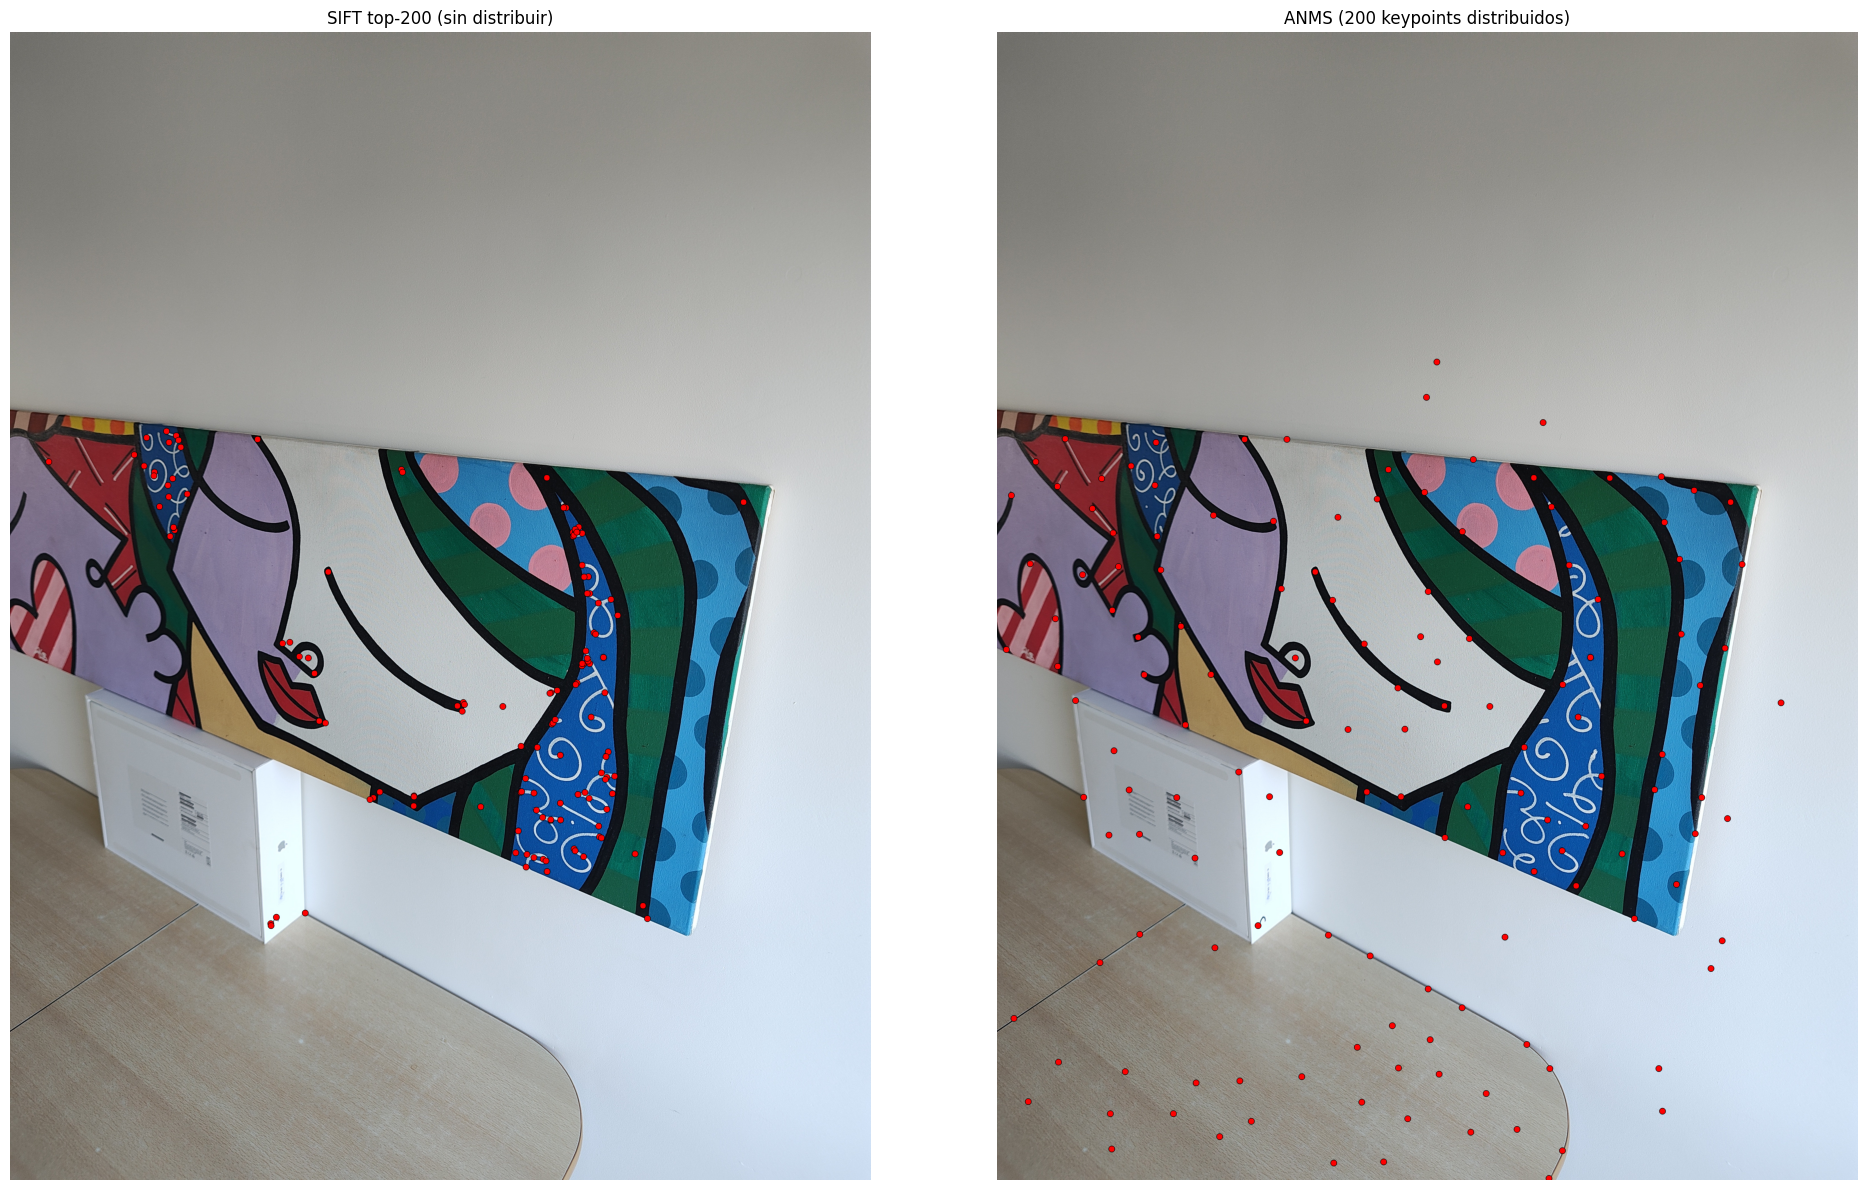

In [49]:
img_anms_2=graf_keypoints(cuadro_2_img,kp_anms2,r=10)
fig, axs = plt.subplots(1, 2, figsize=(20, 12))

axs[0].imshow(cv2.cvtColor(img_kp2, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'SIFT top-{len(kp_cuadro2)} (sin distribuir)')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_anms_2, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'ANMS ({len(kp_anms2)} keypoints distribuidos)')
axs[1].axis('off')

plt.tight_layout()
plt.show()